In [1]:
# cell 1 - mount drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import ADASYN
from collections import Counter
import joblib


In [3]:
# ============================================================
# LOAD FILES
# ============================================================
paths = {
    "train": "/content/drive/My Drive/Embedding_Concatenate_4Class/Train_4class.csv",
    "val":   "/content/drive/My Drive/Embedding_Concatenate_4Class/Val_4class.csv",
    "test":  "/content/drive/My Drive/Embedding_Concatenate_4Class/Test_4class.csv"
}

for k, v in paths.items():
    if not os.path.exists(v):
        raise FileNotFoundError(f"Missing: {v}")
print("All files found!")

train_df = pd.read_csv(paths["train"])
val_df   = pd.read_csv(paths["val"])
test_df  = pd.read_csv(paths["test"])


All files found!


In [4]:
from imblearn.over_sampling import SMOTE

In [5]:
# ============================================================
# EXTRACT X, y
# ============================================================
X_train = train_df.drop(columns=["Label"]).values.astype(np.float32)
y_train = train_df["Label"].values.astype(int)

X_val   = val_df.drop(columns=["Label"]).values.astype(np.float32)
y_val   = val_df["Label"].values.astype(int)

X_test  = test_df.drop(columns=["Label"]).values.astype(np.float32)
y_test  = test_df["Label"].values.astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Original training distribution:", Counter(y_train))

# ============================================================
# 1) UNDERSAMPLE MAJORITY CLASSES (1 = DDoS, 2 = Zero-Day)
# ============================================================
rus = RandomUnderSampler(
    sampling_strategy={
        1: 100000,   # DDoS
        2: 100000    # ZeroDay
    },
    random_state=42
)

X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train)
print("After undersampling:", Counter(y_rus))

# ---------------------------------
# 2) SMOTE for Benign (class 0)
# ---------------------------------
smote = SMOTE(
    sampling_strategy={0: 100000},
    random_state=42,
    k_neighbors=5
)

X_sm, y_sm = smote.fit_resample(X_rus, y_rus)
print("After SMOTE (Benign):", Counter(y_sm))


# ============================================================
# 2) APPLY ADASYN ONLY TO MINORITY CLASS (3 = Malware)
# ============================================================
adasyn = ADASYN(
    sampling_strategy={3: 100000},  # Malware from 5k → 1 lac
    random_state=42,
    n_neighbors=3
)

X_train_bal, y_train_bal = adasyn.fit_resample(X_sm, y_sm)
print("After ADASYN minority class:", Counter(y_train_bal))

Original training distribution: Counter({np.int64(2): 333922, np.int64(1): 170147, np.int64(0): 77336, np.int64(3): 5127})
After undersampling: Counter({np.int64(1): 100000, np.int64(2): 100000, np.int64(0): 77336, np.int64(3): 5127})
After SMOTE (Benign): Counter({np.int64(0): 100000, np.int64(1): 100000, np.int64(2): 100000, np.int64(3): 5127})
After ADASYN minority class: Counter({np.int64(3): 100362, np.int64(0): 100000, np.int64(1): 100000, np.int64(2): 100000})


In [6]:
# ============================================================
# 3) ROC preparation  (only VAL + TEST need binarization)
# ============================================================
classes = np.array([0, 1, 2, 3])
n_classes = 4

# TRAIN is balanced so we DO NOT need ROC for it
y_val_bin  = label_binarize(y_val,  classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)

# ============================================================
# 4) TRAIN RANDOM FOREST
# ============================================================
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_bal, y_train_bal)
print(f"\nTraining completed in {time.time() - start:.2f} seconds.")

# ============================================================
# 5) SAVE MODEL
# ============================================================
model_dir = "/content/drive/My Drive/Ensemble model training/100k_ADASYN_RandomForest_4class"
os.makedirs(model_dir, exist_ok=True)

rf_model_path = os.path.join(model_dir, "random_forest_4class_model.joblib")
joblib.dump(rf_model, rf_model_path)
print("Random Forest model saved to:", rf_model_path)



Training completed in 205.20 seconds.
Random Forest model saved to: /content/drive/My Drive/Ensemble model training/RandomForest_4Class_Balanced/random_forest_4class_model.joblib


In [4]:
# ============================================================
# 6) PREDICTIONS & CLASSIFICATION REPORT (TEST)
# ============================================================

# Load the model if it's not already defined (e.g., after a kernel restart)
import joblib
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN
from collections import Counter
from sklearn.metrics import f1_score, classification_report, confusion_matrix

model_dir = "/content/drive/My Drive/Ensemble model training/100k_ADASYN_RandomForest_4class"
rf_model_path = os.path.join(model_dir, "random_forest_4class_model.joblib")

# Check if rf_model is defined, otherwise load it
if 'rf_model' not in locals() and 'rf_model' not in globals():
    print(f"Loading Random Forest model from: {rf_model_path}")
    rf_model = joblib.load(rf_model_path)

# Re-define paths and load dataframes if not already done
# This ensures the dataframes and scaled/balanced data are available
# even if the kernel state was lost or previous cells weren't run.
if 'test_df' not in locals() and 'test_df' not in globals():
    print("Reloading dataframes and preparing data...")
    paths = {
        "train": "/content/drive/My Drive/Embedding_Concatenate_4Class/Train_4class.csv",
        "val":   "/content/drive/My Drive/Embedding_Concatenate_4Class/Val_4class.csv",
        "test":  "/content/drive/My Drive/Embedding_Concatenate_4Class/Test_4class.csv"
    }
    train_df = pd.read_csv(paths["train"])
    val_df   = pd.read_csv(paths["val"])
    test_df  = pd.read_csv(paths["test"])

    X_train = train_df.drop(columns=["Label"]).values.astype(np.float32)
    y_train = train_df["Label"].values.astype(int)

    X_val   = val_df.drop(columns=["Label"]).values.astype(np.float32)
    y_val   = val_df["Label"].values.astype(int)

    X_test  = test_df.drop(columns=["Label"]).values.astype(np.float32)
    y_test  = test_df["Label"].values.astype(int)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)
    X_test_scaled  = scaler.transform(X_test)

    # Re-apply balancing logic to get X_train_bal, y_train_bal
    rus = RandomUnderSampler(
        sampling_strategy={
            1: 100000,   # DDoS
            2: 100000    # ZeroDay
        },
        random_state=42
    )
    X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train)

    smote = SMOTE(
        sampling_strategy={0: 100000},
        random_state=42,
        k_neighbors=5
    )
    X_sm, y_sm = smote.fit_resample(X_rus, y_rus)

    adasyn = ADASYN(
        sampling_strategy={3: 100000},
        random_state=42,
        n_neighbors=3
    )
    X_train_bal, y_train_bal = adasyn.fit_resample(X_sm, y_sm)
    print("Data preparation complete.")


print("\n=== TEST SET REPORT ===\n")

y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ============================================================
# 7) EVAL FUNCTION FOR TRAIN/VAL/TEST
# ============================================================
def eval_split(name, X, y):
    preds = rf_model.predict(X)
    print(f"\n=== {name} REPORT ===")
    print(classification_report(y, preds, digits=4))

# TRAIN (balanced)
eval_split("TRAIN (Balanced)", X_train_bal, y_train_bal)

# VALIDATION (scaled)
eval_split("VAL", X_val_scaled, y_val)

# TEST (scaled)
eval_split("TEST", X_test_scaled, y_test)

# ============================================================
# 8) MACRO F1 SCORES
# ============================================================

def macro_f1(name, y_true, y_pred):
    score = f1_score(y_true, y_pred, average='macro')
    print(f"{name} Macro F1 Score: {score:.4f}")

macro_f1("TRAIN (Balanced)", y_train_bal, rf_model.predict(X_train_bal))
macro_f1("VAL", y_val, rf_model.predict(X_val_scaled))
macro_f1("TEST", y_test, rf_model.predict(X_test_scaled))

Reloading dataframes and preparing data...
Data preparation complete.

=== TEST SET REPORT ===

              precision    recall  f1-score   support

           0     0.1059    0.0018    0.0036     25519
           1     0.7890    1.0000    0.8821     56715
           2     0.9177    0.9966    0.9555    111324
           3     0.8477    0.9934    0.9148      1961

    accuracy                         0.8677    195519
   macro avg     0.6651    0.7479    0.6890    195519
weighted avg     0.7737    0.8677    0.8095    195519

Confusion Matrix:
 [[    47  15168   9954    350]
 [     0  56715      0      0]
 [   384      0 110940      0]
 [    13      0      0   1948]]

=== TRAIN (Balanced) REPORT ===
              precision    recall  f1-score   support

           0     0.9973    0.0149    0.0294    100000
           1     0.6295    1.0000    0.7726    100000
           2     0.7273    1.0000    0.8421    100000
           3     0.9788    1.0000    0.9893    100362

    accuracy        


===== Confusion Matrix: Train (Balanced) =====
[[  1490  58848  37487   2175]
 [     0  99999      1      0]
 [     4      0  99996      0]
 [     0      0      0 100362]]
Saved: /content/drive/My Drive/Ensemble model training/100k_ADASYN_RandomForest_4class/cm_train.png


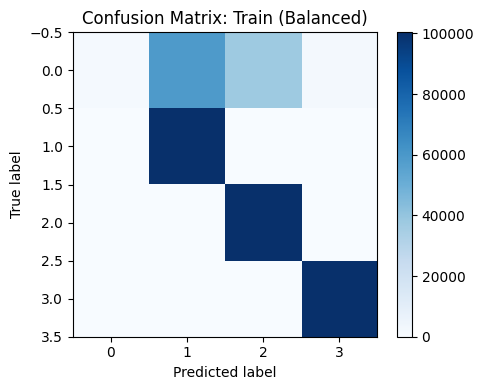


===== Confusion Matrix: Validation =====
[[     3      0      0  25745]
 [     0      0      0  56682]
 [     0      0      0 111309]
 [     9      0      0   1700]]
Saved: /content/drive/My Drive/Ensemble model training/100k_ADASYN_RandomForest_4class/cm_val.png


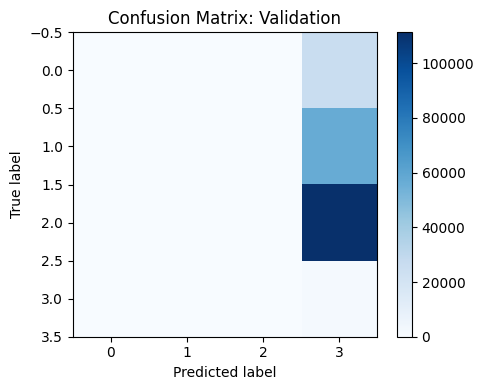


===== Confusion Matrix: Test =====
[[     6      0      0  25513]
 [     0      0      0  56715]
 [     0      0      0 111324]
 [     3      0      0   1958]]
Saved: /content/drive/My Drive/Ensemble model training/100k_ADASYN_RandomForest_4class/cm_test.png


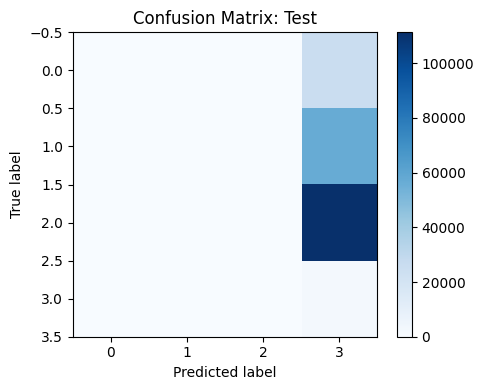

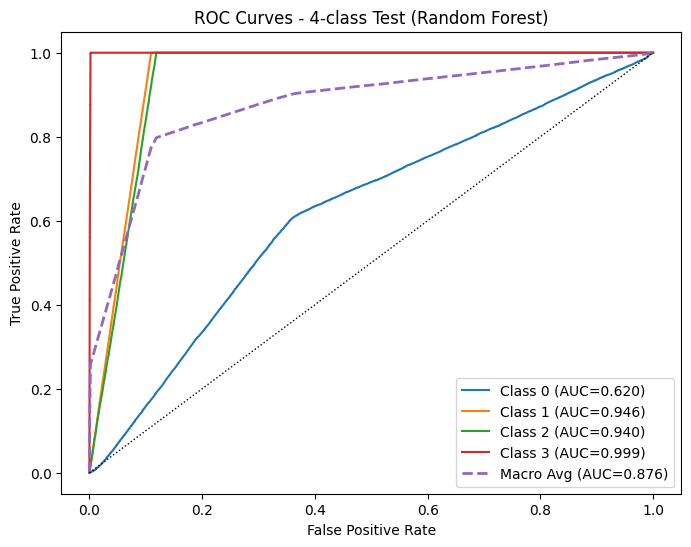

ROC curve saved to: /content/drive/My Drive/Ensemble model training/100k_ADASYN_RandomForest_4class/roc_curve_test.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ============================================================
# 8) CONFUSION MATRIX PLOTTING
# ============================================================

cm_save_path = model_dir
os.makedirs(cm_save_path, exist_ok=True)

def plot_cm_and_save(cm, title, filename):
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.colorbar()
    plt.tight_layout()

    save_file = f"{cm_save_path}/{filename}"
    plt.savefig(save_file)
    print(f"Saved: {save_file}")
    plt.show()

def generate_cm(name, X, y, filename):
    pred = rf_model.predict(X)
    cm = confusion_matrix(y, pred)
    print(f"\n===== Confusion Matrix: {name} =====")
    print(cm)
    plot_cm_and_save(cm, f"Confusion Matrix: {name}", filename)

# IMPORTANT: update TRAIN to balanced data
generate_cm("Train (Balanced)", X_train_bal, y_train_bal, "cm_train.png")

# Validation on original data
generate_cm("Validation", X_val, y_val, "cm_val.png")

# Test on original data
generate_cm("Test", X_test, y_test, "cm_test.png")

# ============================================================
# 9) ROC CURVES (TEST SET ONLY)
# ============================================================

# Ensure classes and n_classes are defined for ROC plotting
classes = np.array([0, 1, 2, 3])
n_classes = 4

# Ensure y_test_bin is available. If the kernel was restarted,
# it might need to be re-binarized.
if 'y_test_bin' not in locals() and 'y_test_bin' not in globals():
    # Assuming y_test is available from the previous cell's data preparation
    y_test_bin = label_binarize(y_test, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro averaging
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} (AUC={roc_auc[i]:.3f})")

plt.plot(fpr["macro"], tpr["macro"], linestyle='--', linewidth=2,
         label=f"Macro Avg (AUC={roc_auc['macro']:.3f})")

plt.plot([0, 1], [0, 1], 'k:', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - 4-class Test (Random Forest)")
plt.legend()

roc_path = f"{cm_save_path}/roc_curve_test.png"
plt.savefig(roc_path)
plt.show()

print("ROC curve saved to:", roc_path)
